In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ripser
from persim import plot_diagrams

print("ripser:", ripser.__version__)

ripser: 0.6.14


In [3]:
# 3 vertices: A=0, B=1, C=2
# Edges: AB, BC, CA
# Filled triangle: ABC

# Boundary matrix ∂1: maps edges → vertices
# Columns = edges [AB, BC, CA]
# Rows    = vertices [A, B, C]
# Convention: edge XY contributes +1 at Y, -1 at X

d1 = np.array([
#   AB   BC   CA
    [-1,   0,  +1],  # A
    [+1,  -1,   0],  # B
    [ 0,  +1,  -1],  # C
], dtype=float)

# Boundary matrix ∂2: maps triangles → edges
# Columns = triangles [ABC]
# Rows    = edges [AB, BC, CA]

d2 = np.array([
#   ABC
    [+1],  # AB
    [+1],  # BC
    [+1],  # CA
], dtype=float)

# Verify fundamental lemma: ∂1 ∘ ∂2 = 0
print("∂1 @ ∂2 =\n", d1 @ d2)
# Should print all zeros — boundary of a boundary is always empty

∂1 @ ∂2 =
 [[0.]
 [0.]
 [0.]]


In [5]:
from numpy.linalg import matrix_rank

def betti(d_k, d_k1):
    """
    βₖ = dim(Ker ∂ₖ) - dim(Im ∂ₖ₊₁)
    Handles the case where d_k1 has zero columns (no higher simplices).
    """
    n_cols  = d_k.shape[1]
    rank_dk = matrix_rank(d_k)
    ker_dim = n_cols - rank_dk

    # If d_k1 has no columns, Im is trivially {0}, so im_dim = 0
    if d_k1.shape[1] == 0:
        im_dim = 0
    else:
        im_dim = matrix_rank(d_k1)

    return ker_dim - im_dim

b0 = 3 - matrix_rank(d1)
b1 = betti(d1, d2)
print(f"β₀ = {b0}")   # expected: 1
print(f"β₁ = {b1}")   # expected: 0  (filled triangle, loop is plugged)

d2_empty = np.zeros((3, 0))
b1_empty = betti(d1, d2_empty)
print(f"\nEmpty triangle: β₁ = {b1_empty}")  # expected: 1

β₀ = 1
β₁ = 0

Empty triangle: β₁ = 1


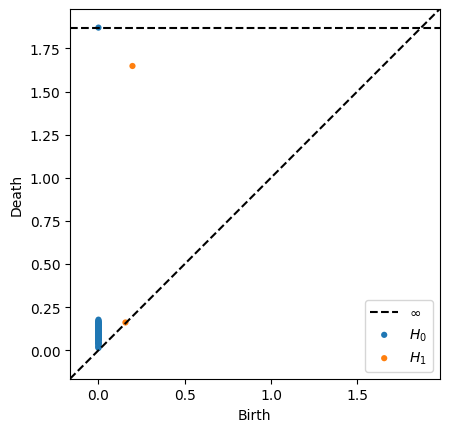

In [9]:
import numpy as np
import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt

theta = np.linspace(0, 2*np.pi, 80)
X = np.column_stack([np.cos(theta), np.sin(theta)])
X += np.random.normal(0, 0.05, X.shape)

result = ripser.ripser(X, maxdim=1)
plot_diagrams(result['dgms'], show=True)

In [1]:
import numpy as np
from numpy.linalg import matrix_rank

class BoundaryMatrix:
    def __init__(self, matrix):
        self.M = np.array(matrix, dtype=int)   # store raw, no mod 2 here

    def reduce(self):
        M = (self.M % 2)                       # mod 2 only during reduction
        n_cols = M.shape[1]
        pivot_col = {}

        for j in range(n_cols):
            rows_with_1 = np.where(M[:, j] == 1)[0]
            while len(rows_with_1) > 0:
                low = rows_with_1[-1]
                if low not in pivot_col:
                    pivot_col[low] = j
                    break
                else:
                    M[:, j] = (M[:, j] + M[:, pivot_col[low]]) % 2
                    rows_with_1 = np.where(M[:, j] == 1)[0]

        self.reduced = M
        self.pivot_col = pivot_col
        return M

    def betti(self, higher_boundary=None):
        n_cols  = self.M.shape[1]
        rank_dk = matrix_rank(self.M)
        ker_dim = n_cols - rank_dk
        if higher_boundary is None or higher_boundary.M.shape[1] == 0:
            im_dim = 0
        else:
            im_dim = matrix_rank(higher_boundary.M)
        return ker_dim - im_dim

In [2]:
# Rebuild d1, d2 using the class
d1 = BoundaryMatrix([
    [-1,  0, +1],   # A: edges AB, BC, CA
    [+1, -1,  0],   # B
    [ 0, +1, -1],   # C
])

d2_filled = BoundaryMatrix([
    [+1],   # AB
    [+1],   # BC
    [+1],   # CA
])

d2_empty = BoundaryMatrix(np.zeros((3, 0), dtype=int))

# Fundamental lemma check (over Z/2Z: mod 2 arithmetic)
print("∂1 @ ∂2 mod 2 =\n", (d1.M @ d2_filled.M) % 2)
# Should be all zeros

# Reduce d1
print("\nReduced ∂1:\n", d1.reduce())
print("Pivots:", d1.pivot_col)

# Betti numbers
b0 = 3 - matrix_rank(d1.M)     # vertices - rank(∂1)
b1_filled = d1.betti(d2_filled)
b1_empty  = d1.betti(d2_empty)

print(f"\nFilled triangle: b0={b0}, b1={b1_filled}")  # b0=1, b1=0
print(f"Empty triangle:  b0={b0}, b1={b1_empty}")    # b0=1, b1=1

∂1 @ ∂2 mod 2 =
 [[0]
 [0]
 [0]]

Reduced ∂1:
 [[1 0 0]
 [1 1 0]
 [0 1 0]]
Pivots: {np.int64(1): 0, np.int64(2): 1}

Filled triangle: b0=1, b1=0
Empty triangle:  b0=1, b1=1


In [3]:
def persistence_pairs(d_k_reduced, d_k1_reduced):
    """
    Extract (birth, death) pairs from reduced boundary matrices.
    
    A column j in reduced ∂_{k+1} with pivot row i means:
      - simplex i (a k-simplex) dies when simplex j (a (k+1)-simplex) appears
      - birth = filtration value of simplex i
      - death  = filtration value of simplex j
    
    Unpaired columns in ∂_k (zero columns after reduction) = 
    features that are born but never die = essential classes.
    """
    pivots = d_k1_reduced.pivot_col   # {row: col} = {dying simplex: killer}
    
    paired_births = set(pivots.keys())
    paired_deaths = set(pivots.values())
    
    n_k_simplices = d_k_reduced.M.shape[1]
    
    essential = []
    for j in range(n_k_simplices):
        col = d_k_reduced.reduced[:, j] if hasattr(d_k_reduced, 'reduced') else d_k_reduced.M[:, j]
        if j not in paired_deaths and not np.any(col):
            essential.append(j)
    
    print(f"Paired (birth simplex -> death simplex): {dict(pivots)}")
    print(f"Essential (never-dying) classes: columns {essential}")
    return pivots, essential

# Reduce both matrices
d1.reduce()
d2_empty.reduce()

print("=== Empty triangle persistence ===")
pairs, essential = persistence_pairs(d1, d2_empty)
# The single H1 class (the loop) should appear as essential — it never dies

=== Empty triangle persistence ===
Paired (birth simplex -> death simplex): {}
Essential (never-dying) classes: columns [2]


In [4]:
# Two separate triangles (no shared vertices)
# Vertices: A,B,C (triangle 1)  D,E,F (triangle 2)
# Edges: AB, BC, CA, DE, EF, FD

d1_two = BoundaryMatrix([
#   AB   BC   CA   DE   EF   FD
    [-1,   0,  +1,   0,   0,   0],  # A
    [+1,  -1,   0,   0,   0,   0],  # B
    [ 0,  +1,  -1,   0,   0,   0],  # C
    [ 0,   0,   0,  -1,   0,  +1],  # D
    [ 0,   0,   0,  +1,  -1,   0],  # E
    [ 0,   0,   0,   0,  +1,  -1],  # F
])

d2_two_empty = BoundaryMatrix(np.zeros((6, 0), dtype=int))

b0_two = 6 - matrix_rank(d1_two.M)
b1_two = d1_two.betti(d2_two_empty)

print(f"Two empty triangles: b0={b0_two}, b1={b1_two}")
# Expected: b0=2 (two components), b1=2 (two loops)

Two empty triangles: b0=2, b1=2


DAY-3 (CELL 9)

In [5]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.spatial.distance import cdist

# Four points forming a rough square
# At increasing epsilon, different simplices appear
points = np.array([
    [0.0, 0.0],   # 0: bottom-left
    [1.0, 0.0],   # 1: bottom-right
    [1.0, 1.0],   # 2: top-right
    [0.0, 1.0],   # 3: top-left
])

# Compute all pairwise distances
D = cdist(points, points)
print("Distance matrix:\n", np.round(D, 3))

# Label every edge with its birth epsilon
edges = [(i, j) for i in range(4) for j in range(i+1, 4)]
edge_births = {(i, j): D[i, j] for i, j in edges}

print("\nEdge birth times (epsilon when edge appears):")
for e, b in sorted(edge_births.items(), key=lambda x: x[1]):
    print(f"  edge {e}: ε = {b:.3f}")

Distance matrix:
 [[0.    1.    1.414 1.   ]
 [1.    0.    1.    1.414]
 [1.414 1.    0.    1.   ]
 [1.    1.414 1.    0.   ]]

Edge birth times (epsilon when edge appears):
  edge (0, 1): ε = 1.000
  edge (0, 3): ε = 1.000
  edge (1, 2): ε = 1.000
  edge (2, 3): ε = 1.000
  edge (0, 2): ε = 1.414
  edge (1, 3): ε = 1.414


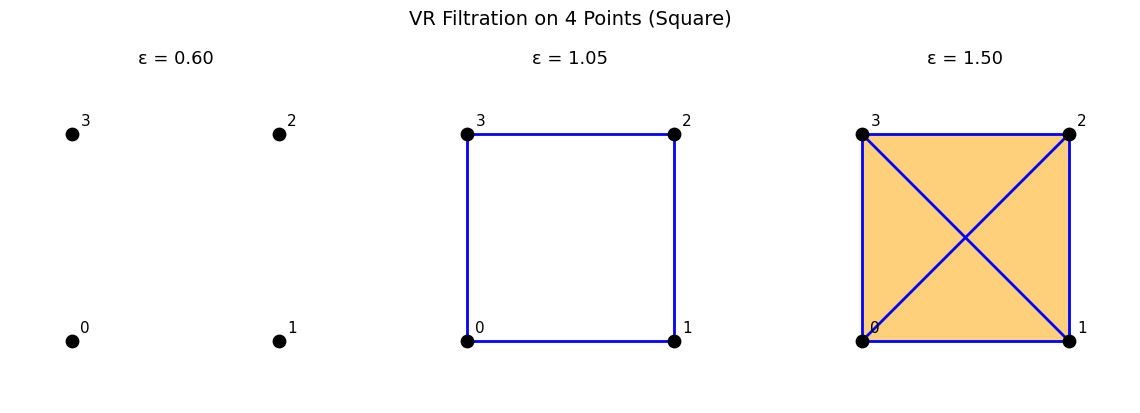

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
epsilons = [0.6, 1.05, 1.5]

for ax, eps in zip(axes, epsilons):
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_aspect('equal')
    ax.set_title(f"ε = {eps:.2f}", fontsize=13)
    ax.axis('off')

    # Draw edges that have appeared
    for (i, j), birth in edge_births.items():
        if birth <= eps:
            x = [points[i, 0], points[j, 0]]
            y = [points[i, 1], points[j, 1]]
            ax.plot(x, y, 'b-', lw=2, zorder=1)

    # Fill triangles if all 3 edges present
    triangles = list(itertools.combinations(range(4), 3))
    for tri in triangles:
        i, j, k = tri
        e1 = tuple(sorted([i, j]))
        e2 = tuple(sorted([i, k]))
        e3 = tuple(sorted([j, k]))
        if all(edge_births[e] <= eps for e in [e1, e2, e3]):
            poly = plt.Polygon(points[[i, j, k]], 
                               alpha=0.3, color='orange', zorder=0)
            ax.add_patch(poly)

    # Draw vertices
    ax.scatter(points[:, 0], points[:, 1], 
               c='black', s=80, zorder=2)
    for idx, p in enumerate(points):
        ax.annotate(str(idx), p, textcoords="offset points", 
                    xytext=(6, 6), fontsize=11)

plt.suptitle("VR Filtration on 4 Points (Square)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Track birth/death of H0 (connected components) by hand
# At eps=0: 4 components (b0=4)
# Each edge that connects two components kills one component
# The last component never dies -> essential H0 class

# Sort edges by birth time
sorted_edges = sorted(edge_births.items(), key=lambda x: x[1])

# Union-Find to track components
parent = list(range(4))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    px, py = find(x), find(y)
    if px == py:
        return False   # already connected — this edge creates a loop
    parent[px] = py
    return True        # merged two components

print("H0 persistence pairs (connected components):")
print(f"  All 4 vertices born at ε = 0.000")
print()

h0_pairs = []
for (i, j), birth in sorted_edges:
    merged = union(i, j)
    if merged:
        # One component dies at this epsilon
        # birth = 0 (vertex), death = this edge's epsilon
        h0_pairs.append((0.0, birth))
        print(f"  Edge {i}-{j} at ε={birth:.3f} → merges components "
              f"→ H0 pair: (birth=0.000, death={birth:.3f})")
    else:
        print(f"  Edge {i}-{j} at ε={birth:.3f} → creates loop (H1 event)")

print(f"\n  1 essential H0 class: (birth=0.000, death=∞)")
print(f"\nAll H0 pairs: {h0_pairs}")
print(f"H0 persistence (lifetime): {[round(d-b,3) for b,d in h0_pairs]}")

H0 persistence pairs (connected components):
  All 4 vertices born at ε = 0.000

  Edge 0-1 at ε=1.000 → merges components → H0 pair: (birth=0.000, death=1.000)
  Edge 0-3 at ε=1.000 → merges components → H0 pair: (birth=0.000, death=1.000)
  Edge 1-2 at ε=1.000 → merges components → H0 pair: (birth=0.000, death=1.000)
  Edge 2-3 at ε=1.000 → creates loop (H1 event)
  Edge 0-2 at ε=1.414 → creates loop (H1 event)
  Edge 1-3 at ε=1.414 → creates loop (H1 event)

  1 essential H0 class: (birth=0.000, death=∞)

All H0 pairs: [(0.0, np.float64(1.0)), (0.0, np.float64(1.0)), (0.0, np.float64(1.0))]
H0 persistence (lifetime): [np.float64(1.0), np.float64(1.0), np.float64(1.0)]


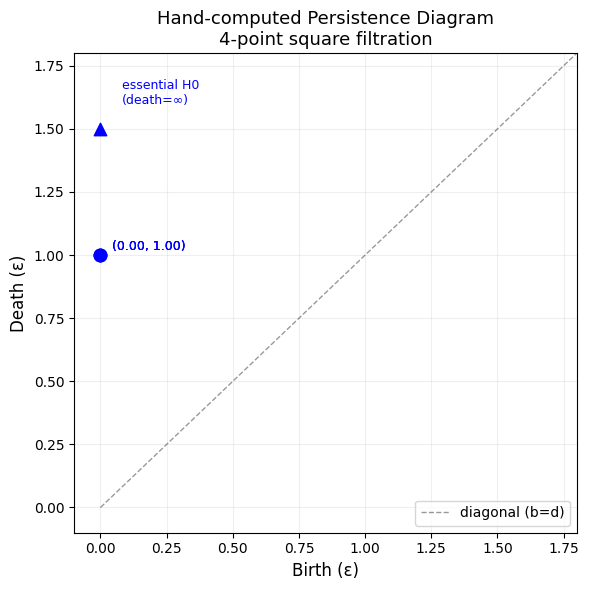


Key insight:
  Points far from diagonal = long-lived features = topologically significant
  Points near diagonal     = short-lived features = noise


In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

# Diagonal
ax.plot([0, 2], [0, 2], 'k--', lw=1, alpha=0.4, label='diagonal (b=d)')

# H0 pairs — finite (blue dots)
for b, d in h0_pairs:
    ax.scatter(b, d, c='blue', s=80, zorder=3)
    ax.annotate(f"({b:.2f}, {d:.2f})", (b, d), 
                textcoords="offset points", xytext=(8, 4), fontsize=9, color='blue')

# H0 essential — infinite (blue arrow pointing up)
ax.annotate("", xy=(0.0, 1.85), xytext=(0.0, 1.5),
            arrowprops=dict(arrowstyle="->", color='blue', lw=1.5))
ax.scatter(0.0, 1.5, c='blue', s=80, zorder=3, marker='^')
ax.text(0.08, 1.6, "essential H0\n(death=∞)", fontsize=9, color='blue')

ax.set_xlabel("Birth (ε)", fontsize=12)
ax.set_ylabel("Death (ε)", fontsize=12)
ax.set_title("Hand-computed Persistence Diagram\n4-point square filtration", fontsize=13)
ax.set_xlim(-0.1, 1.8)
ax.set_ylim(-0.1, 1.8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\nKey insight:")
print("  Points far from diagonal = long-lived features = topologically significant")
print("  Points near diagonal     = short-lived features = noise")

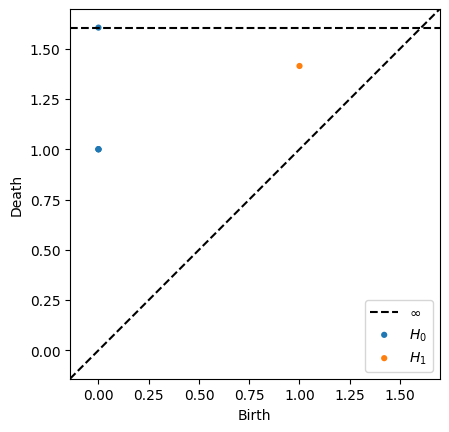


Ripser H0 diagram (birth, death):
  birth=0.000, death=1.000
  birth=0.000, death=1.000
  birth=0.000, death=1.000
  birth=0.000, death=∞

Ripser H1 diagram (birth, death):
  birth=1.000, death=1.414


In [10]:
import ripser
from persim import plot_diagrams

result = ripser.ripser(points, maxdim=1)
plot_diagrams(result['dgms'], show=True)

print("\nRipser H0 diagram (birth, death):")
for pt in result['dgms'][0]:
    d = f"{pt[1]:.3f}" if pt[1] != np.inf else "∞"
    print(f"  birth={pt[0]:.3f}, death={d}")

print("\nRipser H1 diagram (birth, death):")
for pt in result['dgms'][1]:
    d = f"{pt[1]:.3f}" if pt[1] != np.inf else "∞"
    print(f"  birth={pt[0]:.3f}, death={d}")


DAY 4 (CELL 14)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ripser
from persim import plot_diagrams

def takens_embed(signal, dim, tau):
    """
    Takens delay embedding.
    Reconstructs phase space from a 1D time series.

    Parameters
    ----------
    signal : 1D array — the time series
    dim    : int — embedding dimension (2 or 3 for visualization)
    tau    : int — delay (in samples)

    Returns
    -------
    Matrix of shape (N - (dim-1)*tau, dim)
    Each row is a point in the reconstructed phase space.
    """
    N = len(signal)
    n_points = N - (dim - 1) * tau
    X = np.zeros((n_points, dim))
    for i in range(dim):
        X[:, i] = signal[i * tau : i * tau + n_points]
    return X

# Quick sanity check
test_signal = np.array([1, 2, 3, 4, 5, 6, 7, 8])
embedded = takens_embed(test_signal, dim=3, tau=1)
print("Input signal:", test_signal)
print("Embedded (dim=3, tau=1):\n", embedded)
# Row 0 = [1,2,3], Row 1 = [2,3,4], ... each row is a sliding window

Input signal: [1 2 3 4 5 6 7 8]
Embedded (dim=3, tau=1):
 [[1. 2. 3.]
 [2. 3. 4.]
 [3. 4. 5.]
 [4. 5. 6.]
 [5. 6. 7.]
 [6. 7. 8.]]


Signal length: 500
Embedded shape: (438, 3)
Each row is a point in 3D phase space


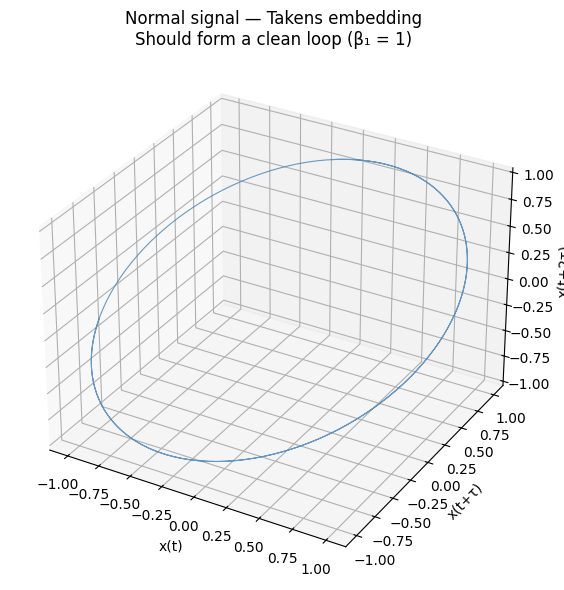

In [12]:
# Simulate a normal periodic signal (proxy for a normal heartbeat)
t = np.linspace(0, 4 * np.pi, 500)
signal_normal = np.sin(t)

# Takens embedding: dim=3, tau chosen to be ~quarter period
# For sin with period 2π over 500 points: period ≈ 125 samples
# quarter period ≈ 31 samples
tau = 31
X_normal = takens_embed(signal_normal, dim=3, tau=tau)

print(f"Signal length: {len(signal_normal)}")
print(f"Embedded shape: {X_normal.shape}")
print(f"Each row is a point in 3D phase space")

# 3D plot
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(X_normal[:, 0], X_normal[:, 1], X_normal[:, 2],
        lw=0.8, color='steelblue', alpha=0.8)
ax.set_title("Normal signal — Takens embedding\nShould form a clean loop (β₁ = 1)", fontsize=12)
ax.set_xlabel("x(t)")
ax.set_ylabel("x(t+τ)")
ax.set_zlabel("x(t+2τ)")
plt.tight_layout()
plt.show()

Normal signal — Ripser H1 diagram:
  birth=0.0357, death=1.9540, persistence=1.9183

Longest-lived H1 feature:
  birth=0.0357, death=1.9540
  persistence = 1.9183

This long-lived feature IS the loop — β₁ = 1 for a normal periodic signal


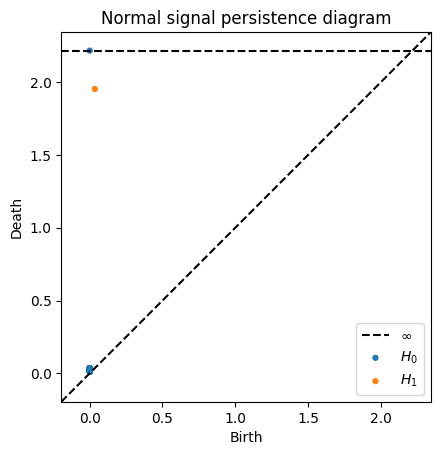

In [13]:
result_normal = ripser.ripser(X_normal, maxdim=1)

print("Normal signal — Ripser H1 diagram:")
for pt in result_normal['dgms'][1]:
    d = f"{pt[1]:.4f}" if pt[1] != np.inf else "∞"
    print(f"  birth={pt[0]:.4f}, death={d}, persistence={pt[1]-pt[0]:.4f}")

# Find the most persistent H1 feature
h1_pairs = result_normal['dgms'][1]
if len(h1_pairs) > 0:
    longest = max(h1_pairs, key=lambda p: p[1] - p[0])
    print(f"\nLongest-lived H1 feature:")
    print(f"  birth={longest[0]:.4f}, death={longest[1]:.4f}")
    print(f"  persistence = {longest[1]-longest[0]:.4f}")
    print(f"\nThis long-lived feature IS the loop — β₁ = 1 for a normal periodic signal")

plot_diagrams(result_normal['dgms'], show=True,
              title="Normal signal persistence diagram")

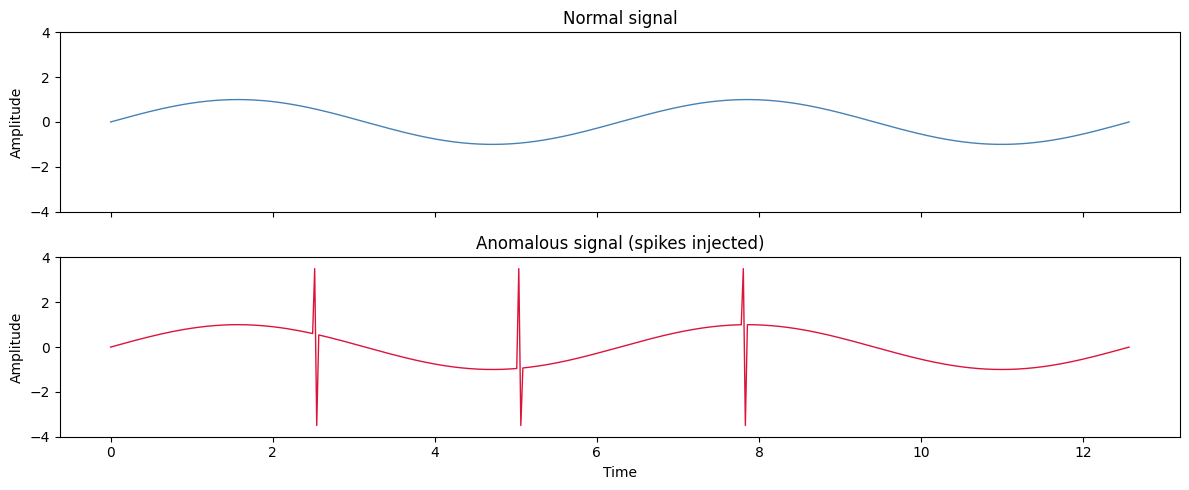

In [14]:
# Start with the same normal signal
signal_anomaly = signal_normal.copy()

# Inject anomalies: sharp spikes at random positions
# This simulates an arrhythmia or sensor fault
np.random.seed(42)
spike_positions = [100, 200, 310]
for pos in spike_positions:
    signal_anomaly[pos] = 3.5    # spike upward
    signal_anomaly[pos + 1] = -3.5  # spike downward

# Plot the two signals for comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t, signal_normal, color='steelblue', lw=1)
axes[0].set_title("Normal signal", fontsize=12)
axes[0].set_ylabel("Amplitude")
axes[0].set_ylim(-4, 4)

axes[1].plot(t, signal_anomaly, color='crimson', lw=1)
axes[1].set_title("Anomalous signal (spikes injected)", fontsize=12)
axes[1].set_ylabel("Amplitude")
axes[1].set_ylim(-4, 4)
axes[1].set_xlabel("Time")

plt.tight_layout()
plt.show()

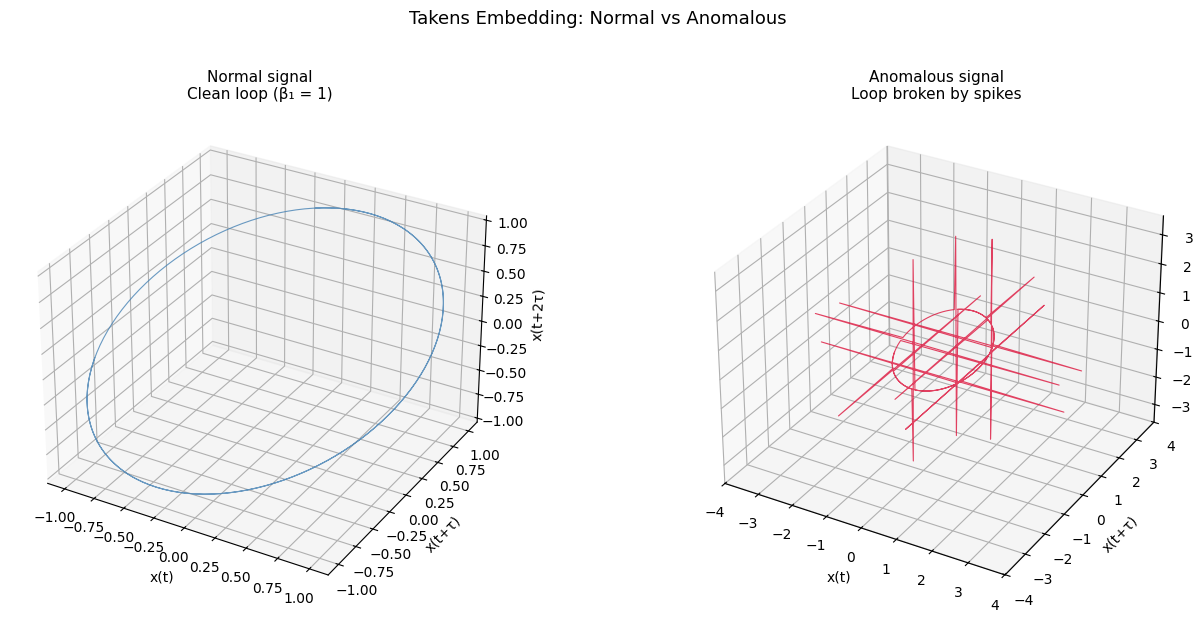

In [15]:
X_anomaly = takens_embed(signal_anomaly, dim=3, tau=tau)

fig = plt.figure(figsize=(14, 6))

# Normal
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(X_normal[:, 0], X_normal[:, 1], X_normal[:, 2],
         lw=0.8, color='steelblue', alpha=0.8)
ax1.set_title("Normal signal\nClean loop (β₁ = 1)", fontsize=11)
ax1.set_xlabel("x(t)"); ax1.set_ylabel("x(t+τ)"); ax1.set_zlabel("x(t+2τ)")

# Anomalous
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(X_anomaly[:, 0], X_anomaly[:, 1], X_anomaly[:, 2],
         lw=0.8, color='crimson', alpha=0.8)
ax2.set_title("Anomalous signal\nLoop broken by spikes", fontsize=11)
ax2.set_xlabel("x(t)"); ax2.set_ylabel("x(t+τ)"); ax2.set_zlabel("x(t+2τ)")

plt.suptitle("Takens Embedding: Normal vs Anomalous", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

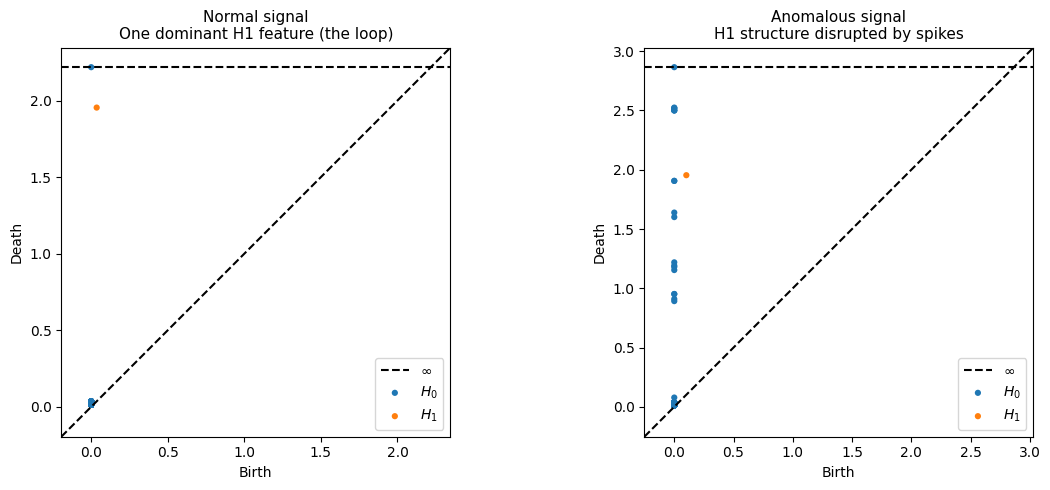

=== Normal signal H1 pairs ===
  birth=0.036, death=1.954, persistence=1.918

=== Anomalous signal H1 pairs ===
  birth=0.102, death=1.954, persistence=1.852

Normal — max H1 persistence  : 1.9183
Anomaly — max H1 persistence : 1.8522

The spike anomalies alter the topological signature of the signal.
This is the mathematical basis for TDA-based anomaly detection.


In [16]:
result_anomaly = ripser.ripser(X_anomaly, maxdim=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normal
plot_diagrams(result_normal['dgms'], ax=axes[0], show=False)
axes[0].set_title("Normal signal\nOne dominant H1 feature (the loop)", fontsize=11)

# Anomalous
plot_diagrams(result_anomaly['dgms'], ax=axes[1], show=False)
axes[1].set_title("Anomalous signal\nH1 structure disrupted by spikes", fontsize=11)

plt.tight_layout()
plt.show()

# Print comparison
print("=== Normal signal H1 pairs ===")
for pt in result_normal['dgms'][1]:
    persistence = pt[1] - pt[0]
    print(f"  birth={pt[0]:.3f}, death={pt[1]:.3f}, persistence={persistence:.3f}")

print("\n=== Anomalous signal H1 pairs ===")
for pt in result_anomaly['dgms'][1]:
    persistence = pt[1] - pt[0]
    print(f"  birth={pt[0]:.3f}, death={pt[1]:.3f}, persistence={persistence:.3f}")

# Quantify the difference
normal_max = max(pt[1]-pt[0] for pt in result_normal['dgms'][1])
anomaly_max = max(pt[1]-pt[0] for pt in result_anomaly['dgms'][1])

print(f"\nNormal — max H1 persistence  : {normal_max:.4f}")
print(f"Anomaly — max H1 persistence : {anomaly_max:.4f}")
print(f"\nThe spike anomalies alter the topological signature of the signal.")
print(f"This is the mathematical basis for TDA-based anomaly detection.")

In [17]:
from persim import wasserstein

# Compare the H1 diagrams of normal vs anomalous
d_wasserstein = wasserstein(
    result_normal['dgms'][1],
    result_anomaly['dgms'][1]
)

print(f"Wasserstein distance between normal and anomalous H1 diagrams:")
print(f"  W = {d_wasserstein:.4f}")
print()
print("In the production pipeline (tda_detect/drift.py):")
print("  - We compute W between a reference window and a new window")
print("  - If W > threshold → drift detected → trigger retraining")
print("  - This is the Topological Wasserstein Drift Detector")
print("  - It's mathematically novel — no off-the-shelf MLOps tool does this")

Wasserstein distance between normal and anomalous H1 diagrams:
  W = 0.0660

In the production pipeline (tda_detect/drift.py):
  - We compute W between a reference window and a new window
  - If W > threshold → drift detected → trigger retraining
  - This is the Topological Wasserstein Drift Detector
  - It's mathematically novel — no off-the-shelf MLOps tool does this
